# Rainfall shocks and food prices in Uganda
**Prices:** WFP monthly retail market prices (HDX), 2011–2026 for seven core markets and late 2018–2026 for Karamoja; WFP wholesale maize, 2006–2022
**Deflator:** FAO consumer price index for Uganda (general, 2015 = 100)
**Controls:** world maize price (IMF via FRED) and the implied shilling–dollar exchange rate
**Rainfall and climate:** CHIRPS regional rainfall and the Indian Ocean Dipole index from the rainfall project

**Questions**
1. How large is the seasonal price cycle, and what does it mean for storing grain?
2. Does a poor rainy season raise real food prices in the months that follow?
3. Does the Indian Ocean Dipole (IOD), known before the second season, predict next year's lean-season prices?
4. How does Karamoja's market behave compared with the rest of the country?

**Design.** Prices are converted to real terms with the CPI, logged, and each market's linear trend and average calendar-month pattern are removed, leaving the unexpected part of the price. For each season, the outcome is that anomaly averaged over the months after harvest:

| Season | Rains | Harvest | Price window |
|---|---|---|---|
| First (A) | March–May | June–August | September–December, same year |
| Second (B) | October–December | December–January | February–May, next year |

Each market is matched to its region's rainfall (Kampala → Central, Lira and Gulu → Northern, Mbarara → Western, Iganga, Kapchorwa and Jinja → Eastern). Regressions include market fixed effects and the world maize price, with standard errors clustered by year, because a rainfall shock hits every market in the same year.

Each finding is written up in a markdown cell directly after the code and output that produced it.

## Setup

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# House style, shared with the rainfall project
WET, DRY, ACCENT, INK, MUTED, GRID = '#2b6c9e', '#c4572e', '#16825a', '#132019', '#7a877f', '#e6e9e4'
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9cfc8', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.labelcolor': MUTED,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)

import statsmodels.formula.api as smf
import prices as P
from prices import (CORE_MARKETS, KARAMOJA_MARKETS, real_log_price, seasonal_profile, season_panel, fit,
                    seasonal_rain_z, load_cpi, load_world_maize)
rng = np.random.default_rng(42)
MON = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

raw = P.load_prices()
core = raw[raw['market'].isin(CORE_MARKETS) & (raw['pricetype'] == 'Retail')]
cov = core[core['commodity'].isin(P.STAPLES)].groupby(['market', 'commodity'])['date'].agg(['min', 'max', 'count'])
cov.unstack('commodity')['count']

commodity,Beans,Maize (white),Maize flour,Sorghum
market,,,,
Gulu,170,169,185,168
Iganga,155,154,170,154
Jinja,96,97,116,97
Kapchorwa,131,131,146,124
Lira,186,166,181,163
Mbarara,168,163,182,157
Owino,200,162,181,158


**Check:** each core market has 95–200 monthly observations per staple, mostly from April 2011 to late 2025. Jinja has the most gaps (about 45% of months missing), Kapchorwa about 25%; the rest are over 85% complete. The consumer price index runs to March 2026, so later prices are dropped when converting to real terms.

In [2]:
# Recording errors: prices more than double or under half the market's centred 7-month median
flagged = P.load_prices(clean=False)
flagged = flagged[flagged['outlier'] & flagged['commodity'].isin(P.STAPLES)
                  & flagged['market'].isin(list(CORE_MARKETS) + KARAMOJA_MARKETS)]
print(f'Removed {len(flagged)} of {len(raw[raw["commodity"].isin(P.STAPLES) & raw["market"].isin(list(CORE_MARKETS) + KARAMOJA_MARKETS)]) + len(flagged):,} staple prices as likely recording errors')
flagged[['date', 'market', 'commodity', 'pricetype', 'price']]

Removed 10 of 6,783 staple prices as likely recording errors


,date,market,commodity,pricetype,price
875,2011-07,Kapchorwa,Beans,Retail,800.00
6786,2020-04,Kaabong,Sorghum,Retail,430.00
7024,2020-07,Karita,Sorghum,Retail,500.00
8361,2021-04,Mbarara,Maize (white),Retail,400.00
8641,2021-06,Gulu,Maize (white),Retail,2.00
11001,2022-02,Lira,Beans,Wholesale,143.82
11548,2022-04,Karita,Sorghum,Retail,2750.00
23101,2024-05,Kapchorwa,Sorghum,Retail,750.00
23651,2024-06,Kapchorwa,Sorghum,Retail,700.00
24116,2024-07,Kapchorwa,Sorghum,Retail,857.00


**Cleaning:** a handful of prices are clearly mis-recorded; the clearest is Gulu maize in June 2021, entered as 2 shillings a kilo against a normal 1,000–2,000. Removing these matters: that single value alone distorted Gulu's seasonal pattern by 25 points. The rule may occasionally remove a genuine spike (Karita sorghum in April 2022 falls in the food crisis), so all removals are listed above.

---
## 1. The seasonal price cycle

In [3]:
rows = {}
for com in ['Maize (white)', 'Sorghum', 'Beans']:
    lp = real_log_price(com, list(CORE_MARKETS) + KARAMOJA_MARKETS)
    for m in lp.columns:
        if lp[m].notna().sum() >= 48:
            rows[(com, m)] = seasonal_profile(lp[m])
prof = pd.DataFrame(rows).T
prof.columns = MON
prof['cheapest'] = prof[MON].idxmin(axis=1)
prof['dearest'] = prof[MON].idxmax(axis=1)
prof['swing_%'] = prof[MON].max(axis=1) - prof[MON].min(axis=1)
prof.round(0)

Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec cheapest dearest  swing_%
Maize (white) Gulu      -10.0  -8.0  -6.0   4.0  15.0  12.0   9.0  -0.0  -9.0  -9.0   1.0   4.0      Jan     May     25.0
              Iganga     -7.0 -13.0  -1.0   8.0  13.0  17.0   3.0  -6.0  -1.0  -2.0  -3.0  -3.0      Feb     Jun     29.0
              Jinja      -9.0  -5.0  -4.0   8.0  16.0  20.0  17.0   1.0 -11.0 -11.0 -10.0  -4.0      Oct     Jun     31.0
              Kaabong   -10.0 -11.0   0.0   8.0  17.0  26.0  17.0   8.0  -3.0 -13.0 -17.0 -10.0      Nov     Jun     43.0
              Kapchorwa  -0.0  -2.0   1.0   2.0  12.0  13.0  18.0   2.0  -4.0 -12.0 -14.0 -10.0      Nov     Jul     33.0
              Karita    -11.0  -4.0  -0.0  10.0   9.0   5.0   5.0  22.0   7.0 -16.0  -8.0 -12.0      Oct     Aug     38.0
              Kotido     -7.0  -6.0  -1.0  -3.0   0.0   5.0  14.0   1.0  -7.0  -4.0   2.0   8.0      Jan     Jul     20.0
              Lira      -12.0  -5.0  -2.0   5.0  17.0  17.0  16.0   3.0  -6.0 -11.0  -9.0  -6.0      Jan     May     29.0
              Makaratin -14.0  -8.0  -9.0  13.0  12.0  18.0  19.0  16.0  -3.0 -12.0 -12.0  -8.0      Jan     Jul     33.0
              Mbarara   -12.0  -9.0  -5.0   2.0   5.0   4.0  10.0   8.0   2.0  -3.0  -3.0   4.0      Jan     Jul     22.0
              Namalu     -6.0   3.0   8.0   9.0  13.0  14.0  11.0   2.0  -7.0 -15.0 -15.0 -11.0      Oct     Jun     29.0
              Owino     -11.0  -6.0   0.0   7.0  13.0  14.0   1.0  -3.0  -2.0  -7.0  -1.0  -2.0      Jan     Jun     25.0
Sorghum       Gulu       -6.0   0.0  -3.0  -0.0   6.0   4.0   1.0   2.0   0.0  -6.0   1.0   1.0      Oct     May     11.0
              Iganga      2.0   3.0   7.0   3.0  -2.0  -5.0  -3.0   0.0  -2.0  -1.0  -2.0  -0.0      Jun     Mar     12.0
              Jinja      -8.0  -3.0  -4.0   4.0  10.0  14.0   2.0   2.0  -5.0  -2.0  -3.0  -5.0      Jan     Jun     22.0
              Kaabong    -9.0 -21.0  -1.0  10.0  10.0  12.0  23.0  15.0   0.0  -6.0 -13.0 -10.0      Feb     Jul     44.0
              Kapchorwa   0.0  -2.0   7.0   4.0   1.0   5.0   3.0   7.0   1.0  -7.0  -9.0  -8.0      Nov     Aug     16.0
              Kotido     -4.0 -11.0  -5.0  -2.0   9.0  17.0  18.0  17.0 -12.0 -14.0  -6.0   3.0      Oct     Jul     32.0
              Lira       -3.0  -4.0  -2.0  -3.0   0.0  -1.0   6.0   2.0   4.0  -4.0   3.0   2.0      Feb     Jul     10.0
              Makaratin -17.0  -9.0 -13.0   1.0  15.0  22.0  22.0  19.0   9.0  -3.0 -15.0 -17.0      Jan     Jul     40.0
              Mbarara     1.0   0.0  -3.0  -1.0   2.0   3.0   4.0   1.0   0.0  -4.0  -3.0  -1.0      Oct     Jul      8.0
              Namalu     -0.0  -2.0   2.0  10.0   7.0  13.0  13.0  -1.0  -9.0 -15.0 -10.0  -3.0      Oct     Jun     28.0
              Owino      -9.0 -11.0  -0.0   0.0   5.0  12.0   2.0   8.0   7.0  -6.0  -1.0  -4.0      Feb     Jun     23.0
Beans         Gulu       -8.0  -6.0  -6.0   8.0  14.0  15.0   3.0  -3.0  -2.0  -3.0  -8.0  -3.0      Nov     Jun     22.0
              Iganga      1.0   2.0   4.0   8.0  11.0   2.0  -7.0  -3.0   4.0  -4.0  -6.0 -10.0      Dec     May     21.0
              Jinja      -8.0  -4.0  -1.0   8.0  13.0  11.0   2.0  -4.0   3.0   1.0  -7.0 -10.0      Dec     May     23.0
              Kaabong   -10.0   1.0   1.0   7.0  12.0  14.0   5.0  -3.0   0.0  -4.0 -11.0 -10.0      Nov     Jun     25.0
              Kapchorwa  -5.0  -0.0  -4.0  11.0  18.0   4.0  -4.0   0.0   2.0  -3.0  -6.0 -10.0      Dec     May     28.0
              Karita     -5.0  -1.0  -5.0   2.0   7.0  12.0  11.0   2.0  -6.0 -10.0  -5.0  -0.0      Oct     Jun     22.0
              Kotido     -5.0  -6.0  -9.0   9.0  11.0  13.0  -0.0  -1.0  -1.0  -3.0  -4.0  -1.0      Mar     Jun     22.0
              Lira       -6.0   5.0   2.0  13.0  18.0   8.0  -4.0  -3.0  -3.0  -3.0 -10.0 -13.0      Dec     May     31.0
              Makaratin  -9.0  -5.0  -8.0   1.0   8.0   8.0  10.0   8.0   4.0  -5.0  -6.0  -4.0      Jan     Jul     19.0


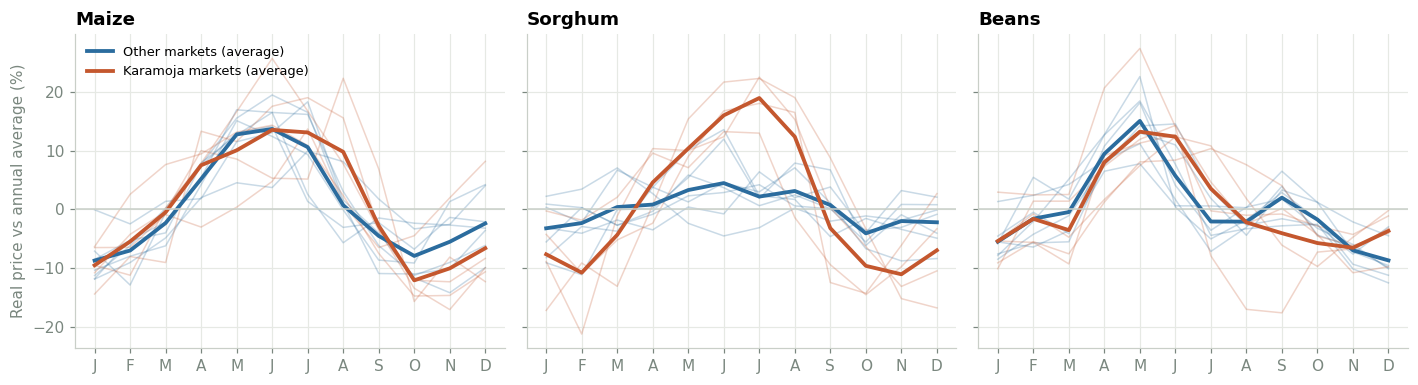

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, com in zip(axes, ['Maize (white)', 'Sorghum', 'Beans']):
    sub = prof.loc[com, MON]
    kar = sub.loc[[m for m in sub.index if m in KARAMOJA_MARKETS]]
    oth = sub.loc[[m for m in sub.index if m not in KARAMOJA_MARKETS]]
    for _, r in oth.iterrows():
        ax.plot(range(12), r.values, color=WET, alpha=.25, lw=1)
    for _, r in kar.iterrows():
        ax.plot(range(12), r.values, color=DRY, alpha=.25, lw=1)
    ax.plot(range(12), oth.mean().values, color=WET, lw=2.5, label='Other markets (average)')
    ax.plot(range(12), kar.mean().values, color=DRY, lw=2.5, label='Karamoja markets (average)')
    ax.axhline(0, color='#c9cfc8', lw=1)
    ax.set_xticks(range(12)); ax.set_xticklabels([m[0] for m in MON])
    ax.set_title(com.split(' (')[0])
axes[0].set_ylabel('Real price vs annual average (%)')
axes[0].legend(loc='upper left', fontsize=8.5)
plt.tight_layout(); plt.show()

**Finding:** real maize prices follow a strong annual cycle: cheapest at harvest (October–February) and dearest in the lean months before the first harvest (May–July). The swing from cheapest to dearest month averages about **30%** across markets (20–43%). Beans follow a similar pattern with a May peak.

The cycle is far larger in **Karamoja for sorghum**, its staple: 28–44% there, against 8–23% elsewhere. Lean-season sorghum in Karamoja (June–August) is the costliest food of the year exactly when household stocks are lowest.

**What it means for farmers.** Selling maize at harvest and buying back in the lean season costs a household about a third of the grain's value. Storing from harvest to the peak earns about 25–30% in real terms on average. That return has to cover storage losses, often 10–20% in traditional storage, and the cost of cash tied up. This is the economic case for hermetic storage bags and warehouse-receipt systems, which cut losses and let farmers borrow against stored grain.

---
## 2. Do poor rainy seasons raise prices?

In [5]:
panels = {com: season_panel(com) for com in P.STAPLES}
rows = []
for com, pan in panels.items():
    for s in ['A', 'B']:
        q = pan[pan['season'] == s]
        for x in ['rain_regional', 'rain_national']:
            for ctrl in [('world',), ('world', 'fx')]:
                r = fit(q, x, ctrl)
                rows.append({'commodity': com, 'season': s, 'rainfall': x, 'controls': ' + '.join(ctrl), **r})
rain_res = pd.DataFrame(rows)
rain_res['dry_pct'] = 100 * (np.exp(-rain_res['coef']) - 1)   # effect of a season one SD DRIER than normal
rain_res.pivot_table(index=['commodity', 'season', 'rainfall'], columns='controls', values=['dry_pct', 'p']).round(3)

dry_pct                 p           
controls                             world world + fx  world world + fx
commodity     season rainfall                                          
Beans         A      rain_national   3.569      3.689  0.079      0.071
                     rain_regional   3.022      3.174  0.225      0.202
              B      rain_national  -3.691     -3.727  0.092      0.086
                     rain_regional  -2.790     -2.824  0.225      0.216
Maize (white) A      rain_national   9.100      9.015  0.002      0.004
                     rain_regional   8.377      8.418  0.004      0.010
              B      rain_national   6.955      7.061  0.092      0.100
                     rain_regional   6.736      6.808  0.093      0.100
Maize flour   A      rain_national   5.448      5.154  0.020      0.047
                     rain_regional   5.225      5.030  0.020      0.054
              B      rain_national   4.084      4.036  0.254      0.260
                     rain_regional   4.612      4.580  0.181      0.184
Sorghum       A      rain_national   4.630      4.573  0.075      0.112
                     rain_regional   3.895      3.934  0.150      0.181
              B      rain_national   8.304      8.050  0.005      0.009
                     rain_regional   9.225      9.010  0.001      0.001

**Reading the table:** `dry_pct` is the change in real prices over the following months when the season's rainfall is one standard deviation **below** normal (roughly a 1-in-6 dry season). Positive values mean dry seasons raise prices.

**Finding:** after the **first season**, maize prices respond clearly: a season one standard deviation drier than normal raises real maize prices by about **8–9%** in September–December (p = 0.002–0.010), with maize flour moving about 5%. After the **second season**, sorghum responds most (about 8–9%, p ≤ 0.009) and maize somewhat (about 7%, p ≈ 0.09–0.10). Controlling for the exchange rate changes nothing. **Beans do not respond** in either season, plausibly because beans are traded more widely across East Africa and are grown in both seasons in most areas, so one poor season is buffered.

Regional and national rainfall give almost identical answers: Uganda's markets are well connected, so a national shortfall moves prices everywhere.

### 2b. How much should we trust this?

In [6]:
def permutation_p(q, x, B=2000):
    q = q.dropna(subset=['price_anom', x, 'world'])
    yearly = q.groupby('year').agg(p=('price_anom', 'mean'), x=(x, 'mean'), w=('world', 'mean'))
    obs = smf.ols('p ~ x + w', yearly).fit()
    null = [smf.ols('p ~ x + w', yearly.assign(x=rng.permutation(yearly['x'].values))).fit().params['x'] for _ in range(B)]
    return obs, (np.sum(np.abs(null) >= abs(obs.params['x'])) + 1) / (B + 1), len(yearly)

checks = [('Maize (white)', 'A', 'rain_national'), ('Maize (white)', 'B', 'rain_national'),
          ('Sorghum', 'B', 'rain_regional'), ('Maize flour', 'A', 'rain_national')]
rows = []
for com, s, x in checks:
    q = panels[com][panels[com]['season'] == s]
    base = fit(q, x)
    loo = [fit(q[q['year'] != y], x)['pct'] for y in sorted(q.dropna(subset=[x])['year'].unique())]
    obs, pp, n = permutation_p(q, x)
    rows.append({'commodity': com, 'season': s, 'rainfall': x, 'panel_pct': base['pct'], 'clustered_p': base['p'],
                 'yearly_pct': 100 * (np.exp(obs.params['x']) - 1), 'permutation_p': pp, 'years': n,
                 'leave_one_year_out_min': min(loo), 'leave_one_year_out_max': max(loo)})
robust = pd.DataFrame(rows)
dry = lambda pct: 100 * (1 / (1 + pct / 100) - 1)   # convert a wetter-season effect to a drier-season one
for c in ['panel_pct', 'yearly_pct', 'leave_one_year_out_min', 'leave_one_year_out_max']:
    robust['dry_' + c] = dry(robust[c])
robust.round(3)

,commodity,season,rainfall,panel_pct,clustered_p,yearly_pct,permutation_p,years,leave_one_year_out_min,leave_one_year_out_max,dry_panel_pct,dry_yearly_pct,dry_leave_one_year_out_min,dry_leave_one_year_out_max
0,Maize (white),A,rain_national,-8.341,0.002,-7.895,0.076,15,-10.243,-7.032,9.100,8.571,11.412,7.563
1,Maize (white),B,rain_national,-6.503,0.092,-6.550,0.146,16,-9.336,-3.807,6.955,7.009,10.297,3.958
2,Sorghum,B,rain_regional,-8.446,0.001,-6.543,0.113,16,-10.103,-7.355,9.225,7.002,11.239,7.939
3,Maize flour,A,rain_national,-5.167,0.020,-5.021,0.181,16,-6.987,-3.867,5.448,5.287,7.512,4.022


In [7]:
# An independent sample: WFP wholesale maize in Kampala, Lira and Busia, 2006–2022
WHOLESALE = {'Owino': 'Central', 'Lira': 'Northern', 'Busia': 'Eastern'}
_retail = P.real_log_price
P.real_log_price = lambda c, m, pricetype='Retail': _retail(c, m, 'Wholesale')
wholesale = P.season_panel('Maize', WHOLESALE)
P.real_log_price = _retail

rows = []
for s, x in [('A', 'rain_national'), ('A', 'rain_regional'), ('B', 'rain_national')]:
    q = wholesale[wholesale['season'] == s]
    base = fit(q, x)
    obs, pp, n = permutation_p(q, x)
    rows.append({'season': s, 'rainfall': x, 'years': f"{q['year'].min()}–{q['year'].max()}", 'panel_pct': base['pct'],
                 'clustered_p': base['p'], 'yearly_pct': 100 * (np.exp(obs.params['x']) - 1), 'permutation_p': pp})
wholesale_res = pd.DataFrame(rows)
wholesale_res['dry_panel_pct'] = 100 * (1 / (1 + wholesale_res['panel_pct'] / 100) - 1)
wholesale_res.round(3)

,season,rainfall,years,panel_pct,clustered_p,yearly_pct,permutation_p,dry_panel_pct
0,A,rain_national,2006–2021,-9.599,0.000,-10.454,0.031,10.619
1,A,rain_regional,2006–2021,-9.871,0.002,-11.763,0.039,10.953
2,B,rain_national,2006–2021,-4.069,0.335,-3.810,0.532,4.241


**Finding:** the size and direction of each effect are very stable. No single year drives them (every leave-one-year-out estimate keeps the same sign and a similar size), and collapsing the markets to one national price per year gives the same estimates. The **certainty is lower than the clustered p-values suggest**, though. With only 15–16 years, a permutation test, which compares the result against thousands of reshuffled rainfall histories, gives p ≈ 0.08–0.18 for the retail results. The seven markets move together, so they add little independent information beyond the number of years.

The **first-season maize result replicates** in an independent sample: WFP's wholesale maize prices for 2006–2021, which include the 2008–09 drought, show an 11% rise per standard deviation of drier March–May rain (permutation p = 0.03–0.04). The second-season maize result does not replicate in the wholesale data.

**Confidence:** *medium* for the first-season maize effect (two datasets, consistent size, permutation p ≈ 0.03–0.08); *suggestive* for the second-season sorghum and maize effects (one dataset).

---
## 3. Can the Indian Ocean Dipole warn of next year's prices?

In [8]:
rows = []
for com in ['Maize (white)', 'Maize flour', 'Sorghum', 'Beans']:
    q = panels[com][panels[com]['season'] == 'B']
    r = fit(q, 'ja_iod')
    obs, pp, n = permutation_p(q, 'ja_iod')
    loo = [fit(q[q['year'] != y], 'ja_iod')['pct'] for y in sorted(q['year'].unique())]
    rows.append({'commodity': com, 'pct_per_degC': r['pct'], 'clustered_p': r['p'], 'permutation_p': pp,
                 'loo_min': min(loo), 'loo_max': max(loo), 'years': n})
iod_res = pd.DataFrame(rows)
iod_res.round(3)

,commodity,pct_per_degC,clustered_p,permutation_p,loo_min,loo_max,years
0,Maize (white),-23.706,0.001,0.019,-26.722,-16.028,16
1,Maize flour,-16.625,0.045,0.091,-20.567,-8.315,17
2,Sorghum,-18.567,0.010,0.079,-21.467,-13.044,16
3,Beans,-1.624,0.802,0.927,-5.841,2.368,18


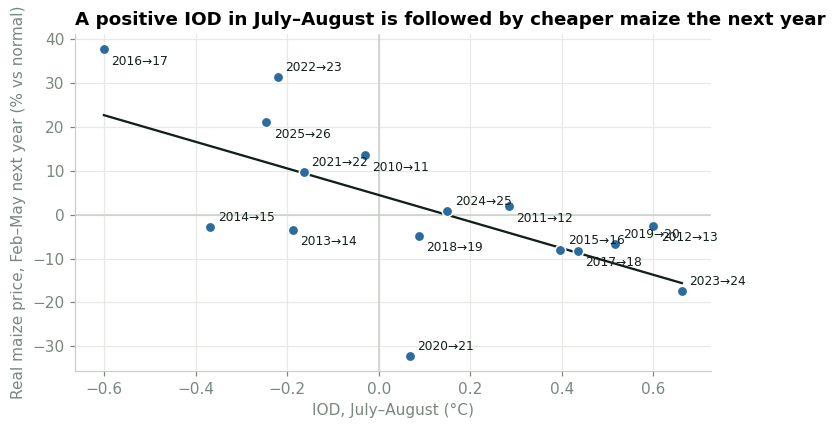

In [9]:
q = panels['Maize (white)'][panels['Maize (white)']['season'] == 'B'].dropna(subset=['ja_iod'])
yearly = q.groupby('year').agg(price=('price_anom', 'mean'), iod=('ja_iod', 'first'))
yearly['price_pct'] = 100 * (np.exp(yearly['price']) - 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.axhline(0, color='#c9cfc8', lw=1); ax.axvline(0, color='#c9cfc8', lw=1)
ax.scatter(yearly['iod'], yearly['price_pct'], s=46, color=WET, edgecolor='white', zorder=3)
for i, (y, r) in enumerate(yearly.sort_values('iod').iterrows()):
    ax.annotate(f'{y}→{(y + 1) % 100:02d}', (r['iod'], r['price_pct']), xytext=(5, 4 if i % 2 else -10), textcoords='offset points', fontsize=8, color=INK)
fit_ = stats.linregress(yearly['iod'], yearly['price_pct'])
xs = np.linspace(yearly['iod'].min(), yearly['iod'].max(), 10)
ax.plot(xs, fit_.intercept + fit_.slope * xs, color=INK, lw=1.5)
ax.set_xlabel('IOD, July–August (°C)'); ax.set_ylabel('Real maize price, Feb–May next year (% vs normal)')
ax.set_title('A positive IOD in July–August is followed by cheaper maize the next year')
plt.tight_layout(); plt.show()

**Finding:** the July–August IOD, known by early September, points to next year's lean-season prices. Each +1 °C of the July–August IOD is followed by real maize prices about **24% lower** the following February–May, and sorghum about 19% lower. Strong positive IOD seasons reach about +0.4 to +0.7 °C, so the practical range is about 10–17%. This fits the rainfall analysis: a positive IOD brings a wetter October–December season, hence a bigger harvest.

**Caution:** this rests on 16 years of retail prices. The permutation p-value is 0.02 for maize and 0.08–0.09 for sorghum and maize flour, and the effect does **not** replicate in the 2006–2021 wholesale maize data. Treat it as a promising early-warning indicator to monitor, not an established forecast. Beans show no IOD effect.

---
## 4. Karamoja

In [10]:
from prices import price_anomaly
def mean_pair_corr(a_cols, b_cols, df):
    vals = []
    for a in a_cols:
        for b in b_cols:
            if a == b or (a_cols is b_cols and a > b):
                continue
            x = df[[a, b]].dropna()
            if len(x) > 24:
                vals.append(x.corr().iloc[0, 1])
    return np.mean(vals)

rows = []
for com in ['Maize (white)', 'Sorghum', 'Beans']:
    lp = real_log_price(com, ['Owino', 'Lira'] + list(CORE_MARKETS) + KARAMOJA_MARKETS).loc['2018-10':'2026-01']
    # Price levels: Karamoja average against Kampala and Lira
    kar_cols = [m for m in KARAMOJA_MARKETS if m in lp]
    kar = lp[kar_cols].mean(axis=1)
    gaps = {ref: 100 * (np.exp((kar - lp[ref]).dropna()) - 1).mean() for ref in ['Owino', 'Lira']}
    # Co-movement: correlation of trend- and season-adjusted price anomalies, same period for every pair
    an = pd.DataFrame({m: price_anomaly(lp[m]) for m in lp.columns if lp[m].notna().sum() >= 48})
    k = [m for m in an if m in KARAMOJA_MARKETS]
    c = [m for m in an if m in CORE_MARKETS]
    rows.append({'commodity': com, 'gap_vs_Kampala_%': gaps['Owino'], 'gap_vs_Lira_%': gaps['Lira'],
                 'co-movement core-core': mean_pair_corr(c, c, an), 'co-movement Karamoja-core': mean_pair_corr(k, c, an),
                 'co-movement Karamoja-Karamoja': mean_pair_corr(k, k, an)})
integration = pd.DataFrame(rows).set_index('commodity')
integration.round(2)

,gap_vs_Kampala_%,gap_vs_Lira_%,co-movement core-core,co-movement Karamoja-core,co-movement Karamoja-Karamoja
commodity,,,,,
Maize (white),-20.48,22.45,0.72,0.67,0.71
Sorghum,-48.24,12.53,0.28,0.39,0.58
Beans,-2.97,1.98,0.66,0.36,0.33


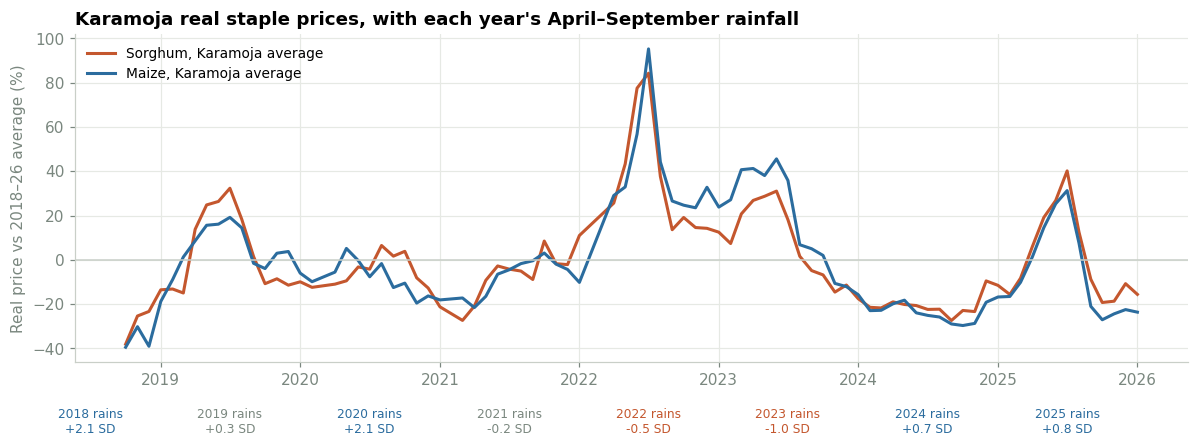

year
2018    2.05
2019    0.28
2020    2.05
2021   -0.20
2022   -0.50
2023   -0.98
2024    0.69
2025    0.78
Name: rainfall_mm, dtype: float64

In [11]:
import matplotlib.dates as mdates
kar_rain = seasonal_rain_z([4, 5, 6, 7, 8, 9]).xs('Karamoja')   # Karamoja's single April–September season
fig, ax1 = plt.subplots(figsize=(11, 4.4))
for com, c in [('Sorghum', DRY), ('Maize (white)', WET)]:
    lp = real_log_price(com, KARAMOJA_MARKETS).loc['2018-10':]
    k = 100 * (np.exp(lp.mean(axis=1)) / np.exp(lp.mean(axis=1)).mean() - 1)
    ax1.plot(k.index.to_timestamp(), k.values, color=c, lw=2, label=f'{com.split(" (")[0]}, Karamoja average')
ax1.axhline(0, color='#c9cfc8', lw=1)
ax1.set_ylabel('Real price vs 2018–26 average (%)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Karamoja real staple prices, with each year\'s April–September rainfall')
for y in range(2018, 2026):
    z = kar_rain.get(y)
    ax1.annotate(f'{y} rains\n{z:+.1f} SD', (mdates.date2num(pd.Timestamp(f'{y}-07-01')), 0), xycoords=ax1.get_xaxis_transform(),
                 xytext=(0, -30), textcoords='offset points', ha='center', va='top', fontsize=8,
                 color=DRY if z <= -0.5 else WET if z >= 0.5 else MUTED)
plt.tight_layout(); plt.subplots_adjust(bottom=0.24); plt.show()
kar_rain.loc[2018:2025].round(2)

**Finding:** Karamoja's **maize and sorghum markets are nearly as connected to the rest of the country as the other markets are to each other.** After removing trends and seasonal patterns, Karamoja's maize prices move with the core markets nearly as closely (correlation 0.67) as the core markets move with one another (0.72); for sorghum the link is, if anything, stronger (0.39 against 0.28). Only **beans** are noticeably less connected (0.36 against 0.66).

The price *levels* show Karamoja's position in the grain trade: maize there costs about 20% less than in Kampala but about 22% **more** than in Lira, the nearby surplus-producing area, consistent with a deficit region buying in grain and paying the transport cost.

What sets Karamoja apart is therefore not isolation but **exposure**: the largest seasonal swing in its staple (sorghum, up to 44%), and the sharpest crisis spikes. Local harvests therefore matter more for local prices, and a shortfall is not quickly offset by grain flowing in.

The **2022 food crisis** is visible: real maize and sorghum prices averaged over 40% above their 2018–26 norm for the year and peaked at nearly double it in June–July 2022. The timing matters. Prices started climbing in early 2022 and peaked in the lean season *before* that year's harvest, so the 2022 rains can't explain the spike. It coincides with the global grain price shock that followed Russia's invasion of Ukraine in February 2022, with insecurity in the region, and with national shortages after poor 2021 seasons elsewhere in Uganda: satellite crop greenness (notebook 03) shows Karamoja's own crops near normal in 2021–22 while the rest of the country had some of its worst seasons on record. The below-average 2022 and 2023 seasons then kept prices high into 2023, and prices fell back only after the better 2024 season. Sorghum in Karamoja is usually much cheaper than in Kampala (about 50% less), but its lean-season spikes are the sharpest anywhere in the data.

With only seven seasons of Karamoja prices, the rainfall–price link there can't be estimated reliably yet; this section is descriptive.

---
## Export

In [12]:
out = Path('../data/processed') if 'Path' in dir() else None
from pathlib import Path
out = Path('../data/processed'); out.mkdir(exist_ok=True)
prof.round(2).to_csv(out / 'seasonal_price_profiles.csv')
rain_res.round(4).to_csv(out / 'rainfall_price_effects.csv', index=False)
robust.round(4).to_csv(out / 'rainfall_price_robustness.csv', index=False)
iod_res.round(4).to_csv(out / 'iod_price_effects.csv', index=False)
integration.round(4).to_csv(out / 'karamoja_market_integration.csv')
wholesale_res.round(4).to_csv(out / 'wholesale_replication.csv', index=False)
print('Saved 6 tables to data/processed/')

Saved 6 tables to data/processed/


---
## Summary

**What the prices show**
- **The seasonal cycle is the biggest, most predictable price risk.** Real maize prices swing about 30% between harvest and the lean season every year; sorghum in Karamoja swings up to 44%.
- **A dry first season raises maize prices** by about 9–11% per standard deviation of rainfall shortfall, in both retail (2011–2025) and wholesale (2006–2021) data. *Medium confidence.*
- **A dry second season raises sorghum prices** by about 8–9%. *Suggestive; one dataset.*
- **A positive July–August IOD is followed by cheaper maize and sorghum** the next February–May. *Suggestive; not replicated in wholesale data.*
- **Beans don't respond** to Ugandan rainfall.
- **Karamoja's maize and sorghum prices move with the national market**, but its staple's seasonal swing is the largest in the country, and real prices ran over 40% above normal in the 2022 crisis.

**Caveats**
- 15–16 years of prices limit statistical certainty; the permutation tests are the honest measure.
- Retail prices in seven towns stand in for the prices farmers receive, which are lower and swing more.
- The CPI deflator is national; regional inflation can differ.

**Next steps**
1. Add satellite vegetation (NDVI) over cropland as an independent measure of harvest outcomes, to test the rainfall → harvest → price chain directly.
2. Extend to the regional price data from FEWS NET and the East African Grain Council to lengthen the record.
3. Quantify the storage decision: real returns to storage net of loss rates and interest, by market.